In [4]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
df  = pd.read_csv("./final-employee-ds.csv")

print(df)

    EmployeeID          Name  Age  Gender  Department  ExperienceYears  \
0          101    Employee_1   50    Male          IT               17   
1          102    Employee_2   36    Male     Finance                1   
2          103    Employee_3   29    Male   Marketing               16   
3          104    Employee_4   42    Male   Marketing               12   
4          105    Employee_5   40  Female     Finance               19   
..         ...           ...  ...     ...         ...              ...   
95         196   Employee_96   58  Female   Marketing                9   
96         197   Employee_97   56    Male          IT               12   
97         198   Employee_98   43  Female  Management                1   
98         199   Employee_99   48    Male   Marketing                1   
99         200  Employee_100   56  Female          HR               15   

      Salary  WorkHoursPerWeek  PerformanceScore    JoinDate Tshirt_size  \
0    86175.0                44     

Question : 1
20 Marks
Load the TrainingHours column into a NumPy array.
Convert to float datatype


Find mean & standard deviation

Final output: Two numeric values


In [6]:
## get TraningHours  Data
training_hours = df['TrainingHours'].to_numpy().astype(float)

## Calculate mean
mean_value = np.mean(training_hours);
## calculate standard  deviation
std_deviation = np.std(training_hours)

# print result
print(f"Mean: {mean_value}")

print(f"Standard Deviation: {std_deviation}")

Mean: 24.19
Standard Deviation: 13.842467265628624


Question : 2
20 Marks
Handle missing values (if any):
Fill missing Salary with department-wise median


Calculate total Salary sum for employees with ExperienceYears > 12 and ProjectCount > 5

Final output: One numeric value


In [7]:
## fill the missing values
df['Salary'] = df.groupby('Department')['Salary'].transform(
    lambda x: x.fillna(x.median())
)
## fiter employees  expirence Years   12 and projectcount  5 more or then
filtered_df = df[(df['ExperienceYears'] > 12) & (df['ProjectCount'] > 5)]

## calculate total salary sum
total_salary = filtered_df['Salary'].sum()

print(f"Total Salary Sum: {total_salary}")

Total Salary Sum: 1985775.5


Question : 3
20 Marks

Filter employees who:
Department = "IT" or "Finance"


Age between 30–45


PerformanceScore > 88


Sort by Salary descending

Final output: Table with Name, Department, Salary, PerformanceScore


In [8]:
## filter employee based  on conditions
filtered_df = df[
    (df['Department'].isin(['IT', 'Finance'])) &  # Department is IT or Finance
    (df['Age'] >= 30) & (df['Age'] <= 45) &        # Age between 30-45
    (df['PerformanceScore'] > 88)                   # PerformanceScore > 88
]

# sort salary decending
filtered_df = filtered_df.sort_values(by='Salary', ascending=False)

# Select only required columns
result = filtered_df[['Name', 'Department', 'Salary', 'PerformanceScore']]
print(result)
## save csv file
result.to_csv('filtered_employees.csv', index=False)

           Name Department    Salary  PerformanceScore
94  Employee_95         IT  140386.0                94
88  Employee_89    Finance  126027.0                92
4    Employee_5    Finance   85543.0                97
32  Employee_33         IT   83919.0                98
55  Employee_56    Finance   49540.0                94


Question : 4
20 Marks
Add new column SalaryPerHour = Salary ÷ (WorkHoursPerWeek × 4)
Filter top 5 employees by SalaryPerHour

Final output: Table(5 Rows) with Name, SalaryPerHour


In [9]:
# add new colum salary per hour
df['SalaryPerHour'] = df['Salary'] / (df['WorkHoursPerWeek'] * 4)
# sorting by  salary perhour  colum
top_5 = df.nlargest(5, 'SalaryPerHour')
# select only required colums
result = top_5[['Name', 'SalaryPerHour']]
print(result)
result['SalaryPerHour'] = result['SalaryPerHour'].round(2)
print(result.to_string(index=False))

           Name  SalaryPerHour
46  Employee_47     981.278571
27  Employee_28     971.292857
31  Employee_32     967.392857
79  Employee_80     945.335526
80  Employee_81     937.858974
       Name  SalaryPerHour
Employee_47         981.28
Employee_28         971.29
Employee_32         967.39
Employee_80         945.34
Employee_81         937.86


C:\Users\mosto\AppData\Local\Temp\ipykernel_22512\1561732920.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['SalaryPerHour'] = result['SalaryPerHour'].round(2)


Question : 5
20 Marks
Create a stacked bar chart showing the count of employees in each Department, separated by Gender.
Dataset Columns Used:
Department → Categorical variable (IT, Finance, HR, Marketing, Management)


Gender → Categorical variable (Male, Female)

Expected Output
A stacked bar chart where:


x-axis → Department


y-axis → Number of employees


Each bar split into Male and Female segments


Colors differentiate gender


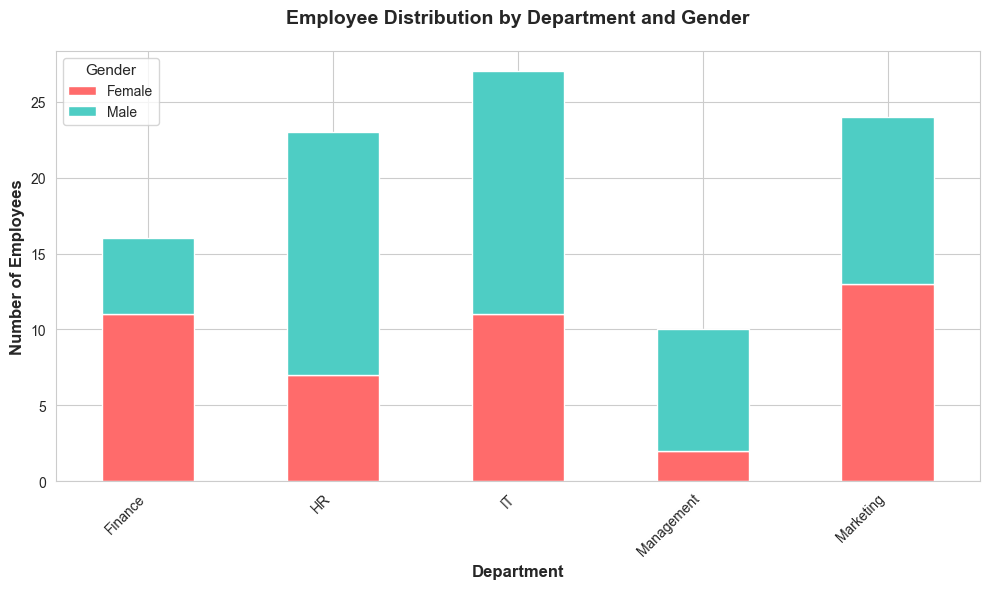

In [10]:
# Set style
sns.set_style("whitegrid")

# Create count data
gender_dept_count = df.groupby(['Department', 'Gender']).size().reset_index(name='Count')

# Pivot for stacked bar
pivot_data = gender_dept_count.pivot(index='Department', columns='Gender', values='Count').fillna(0)

# Create stacked bar chart
ax = pivot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#FF6B6B', '#4ECDC4']
)

plt.xlabel('Department', fontsize=12, fontweight='bold')
plt.ylabel('Number of Employees', fontsize=12, fontweight='bold')
plt.title('Employee Distribution by Department and Gender', fontsize=14, fontweight='bold', pad=20)
plt.legend(title='Gender', title_fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()